<a href="https://colab.research.google.com/github/calebwoodham-cyber/jfugitt-cwoodham-project2-5215-4205/blob/GCollab-Branch/ImageRec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

random_number = random.randint(1, 2000)
print(random_number)

SEED = random_number
random.seed(SEED)
tf.random.set_seed(SEED)                       # For reproducability.
np.random.seed(SEED)               # ensures numpy-level reproducibility too

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import SGD

from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

tf.config.run_functions_eagerly(True)

1225


In [ ]:
output_file = "/content/drive/MyDrive/ImageRec/Seeds.txt"

In [ ]:

#*************************************************************************************************************************************
#Starter code: import dataset
#*************************************************************************************************************************************
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
#*************************************************************************************************************************************
# starter code: read in datasets
#*************************************************************************************************************************************

kaggle_prefix = "" # Note: If we simply put empty string, then the entire code will run in google colab without any issues.

#  read in the annotations

data_og = pd.read_csv('/kaggle/input/celeba-dataset/list_attr_celeba.csv')

#  read in the landmarks
landmarks = pd.read_csv('/kaggle/input/celeba-dataset/list_landmarks_align_celeba.csv')

# read in the partitions to discover train, validation and test segments
partition = pd.read_csv('/kaggle/input/celeba-dataset/list_eval_partition.csv')

# selecting only male and bushy eyebrows features. We will also need image_id for unique identfication of these images
data = data_og[['image_id', 'Male','Young', 'Mustache','Goatee','No_Beard','5_o_Clock_Shadow']]

LABEL_COLS = [col for col in data.columns if col != 'image_id'] #defines labels for the columns inside of data, excluding image_id
print(LABEL_COLS)

# Dynamically replace -1 with 0 for all label columns
for col in LABEL_COLS:
    data[col] = data[col].replace({-1: 0})

# perform an inner join of the result with the partition data frame on image_id to obtain integrated partitions
df = pd.merge(data, partition, on='image_id', how='inner')

['Male', 'Young', 'Mustache', 'Goatee', 'No_Beard', '5_o_Clock_Shadow']


In [ ]:
#*************************************************************************************************************************************
#starter code: split partitions
#*************************************************************************************************************************************

train_df = df[df['partition'] == 0] #if partition number = 0, that goes into the train df variable
test_df = df[df['partition'] == 1]
val_df = df[df['partition'] == 2]

In [ ]:
#*************************************************************************************************************************************
#starter code: sample partitions
#*************************************************************************************************************************************
train_df = train_df.sample(frac=0.2, random_state=SEED)
train_df.head()
print (len(train_df))

val_df = val_df.sample(n=2000, random_state=SEED)
val_df.head()
print (len(val_df))
test_df = test_df.sample(n=2000, random_state=SEED)
print(len(test_df))
print(test_df.head())

32554
2000
2000
          image_id  Male  Young  Mustache  Goatee  No_Beard  5_o_Clock_Shadow  \
172624  172625.jpg     0      1         0       0         1                 0   
173862  173863.jpg     0      1         0       0         1                 0   
171599  171600.jpg     1      1         0       1         0                 0   
167691  167692.jpg     0      1         0       0         1                 0   
170396  170397.jpg     1      1         0       1         0                 0   

        partition  
172624          1  
173862          1  
171599          1  
167691          1  
170396          1  


In [ ]:
print(len(train_df), len(val_df), len(test_df))

32554 2000 2000


In [ ]:
print(f"Attributes: \n{data.head(10)}\n\n")
print(f"Landmarks: \n{landmarks.head(2)}\n\n")
print(f"partitions: \n{partition.head(2)}\n\n")

print(f"Training Data: \n{train_df.head(2)}\n\n")
print(f"Validation Data: \n{val_df.head(2)}\n\n")
print(f"Test Data: \n{test_df.head(2)}\n\n")

Attributes: 
     image_id  Male  Young  Mustache  Goatee  No_Beard  5_o_Clock_Shadow
0  000001.jpg     0      1         0       0         1                 0
1  000002.jpg     0      1         0       0         1                 0
2  000003.jpg     1      1         0       0         1                 0
3  000004.jpg     0      1         0       0         1                 0
4  000005.jpg     0      1         0       0         1                 0
5  000006.jpg     0      1         0       0         1                 0
6  000007.jpg     1      1         0       0         1                 1
7  000008.jpg     1      1         0       0         1                 1
8  000009.jpg     0      1         0       0         1                 0
9  000010.jpg     0      1         0       0         1                 0


Landmarks: 
     image_id  lefteye_x  lefteye_y  righteye_x  righteye_y  nose_x  nose_y  \
0  000001.jpg         69        109         106         113      77     142   
1  000002.jp

In [ ]:
#*************************************************************************************************************************************
#starter code: Data generator class
#*************************************************************************************************************************************

# Data generator class - this is a key class that is used to batch the data so as to
# reduce compute time as well as to fit training segments into available memory
# Additionally it allows you to specify multiple targets for classification
# Also allows for image cropping
from tensorflow.keras.preprocessing import image
from tensorflow.python.keras.utils import np_utils

class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, df, label_cols, batch_size=32, dim=(218,178), n_channels=3, n_classes=2, shuffle=False):
        self.dim = dim
        self.batch_size = batch_size
        self.df = df
        self.label_cols = label_cols
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size)) # Modified code here to include the last batch as well.

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        # saves memory by batching
        df_temp = self.df.iloc[indexes].reset_index(drop=True)
        X, y = self.__data_generation(df_temp)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.df))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, df_temp):
        # Adjust for the last batch which might be smaller
        current_batch_size = len(df_temp)
        X = np.empty((current_batch_size, *self.dim, self.n_channels))
        y = np.empty((current_batch_size, self.n_classes),dtype=int)

        for i, row in df_temp.iterrows():
                img_path ='/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/' + row[0]
                img = image.load_img(img_path, target_size=self.dim)
                img = image.img_to_array(img)
                img /= 255.0
                X[i,] = img
                y[i,] = row[self.label_cols].values.astype(np.float32) # need to assign y[i,] accordingly to the row object to specify the target(s) for the query.
        return X, y

In [ ]:
#*************************************************************************************************************************************
# starter code: # lengths of dfs
#*************************************************************************************************************************************
print(f"Lengths of train, validation and test partitions: {len(train_df), len(test_df), len(val_df)}")

Lengths of train, validation and test partitions: (32554, 2000, 2000)


In [ ]:
#*************************************************************************************************************************************
# starter code: # using vgg16 as feature extractor
#*************************************************************************************************************************************

vgg16 = tf.keras.applications.VGG16(input_shape=(218, 178, 3), include_top=False, weights='imagenet')
vgg16.trainable = True

# creating the model
model = tf.keras.Sequential([
    vgg16,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(len(LABEL_COLS), activation='sigmoid')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
#*************************************************************************************************************************************
# starter code: compiling the model
#*************************************************************************************************************************************
model.compile(optimizer=SGD(learning_rate=0.0001), loss='binary_crossentropy', metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5)])



In [ ]:
#*************************************************************************************************************************************
# starter code: creating the train, test and validation data generators
#*************************************************************************************************************************************
train_generator = DataGenerator(train_df,LABEL_COLS, batch_size=32, dim=(218,178), n_channels=3,n_classes=len(LABEL_COLS), shuffle=True)
test_generator = DataGenerator(test_df,LABEL_COLS, batch_size=32, dim=(218,178), n_channels=3,n_classes=len(LABEL_COLS), shuffle=False)
val_generator = DataGenerator(val_df,LABEL_COLS, batch_size=32, dim=(218,178), n_channels=3,n_classes=len(LABEL_COLS), shuffle=False)

training = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 307s 294ms/step - binary_accuracy: 0.8266 - loss: 0.4309 - val_binary_accuracy: 0.8819 - val_loss: 0.3330


In [ ]:
#*************************************************************************************************************************************
#starter code: checking test generator
#*************************************************************************************************************************************

import sys
print(test_generator[0][0][0].shape)
print(sys.getsizeof(test_generator[0][0][0]))
print(test_generator[0][0][0])

(218, 178, 3)
144
[[[0.27450982 0.30588236 0.31764707]
  [0.27843139 0.30980393 0.32156864]
  [0.27843139 0.30980393 0.32156864]
  ...
  [0.44705883 0.49803922 0.52941179]
  [0.45882353 0.49411765 0.52156866]
  [0.45490196 0.49019608 0.51764709]]

 [[0.27450982 0.30588236 0.31764707]
  [0.27843139 0.30980393 0.32156864]
  [0.27843139 0.30980393 0.32156864]
  ...
  [0.44313726 0.49411765 0.52549022]
  [0.44705883 0.48235294 0.50980395]
  [0.44313726 0.47843137 0.50588238]]

 [[0.27450982 0.30588236 0.31764707]
  [0.27843139 0.30980393 0.32156864]
  [0.27843139 0.30980393 0.32156864]
  ...
  [0.4627451  0.51372552 0.54509807]
  [0.44705883 0.48235294 0.50980395]
  [0.43921569 0.47450981 0.50196081]]

 ...

 [[0.29803923 0.23921569 0.21960784]
  [0.35294119 0.29411766 0.26666668]
  [0.3137255  0.23529412 0.2       ]
  ...
  [0.1882353  0.1882353  0.1882353 ]
  [0.1882353  0.1882353  0.1882353 ]
  [0.19215687 0.19215687 0.19215687]]

 [[0.3137255  0.24705882 0.21960784]
  [0.32549021 0.258

In [ ]:

#*************************************************************************************************************************************
#Starter code: evaluate model
#*************************************************************************************************************************************

print(model.evaluate(test_generator,batch_size=32))

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - binary_accuracy: 0.8562 - loss: 0.3859
[0.38111749291419983, 0.8589168190956116]


In [ ]:
#*************************************************************************************************************************************
#Starter code: predict on unseen data
#*************************************************************************************************************************************

prediction = model.predict(test_generator)
test_array=test_df.to_numpy()
count=0
#print(test_df.head(10))
#print(prediction[:,:])
for pred in prediction:
    if(count<29): count=count+1 #print(pred)

test_size=len(test_df)
correct=0

#print(prediction[1,0])
#print(prediction[1,1])
for i in range(test_size):
    pred_class1 = prediction[i,0]
    pred_class2= prediction[i,1]
    test_class1 = test_array[i,1]
    test_class2= test_array[i,2]

    if((np.where(pred_class1 > 0.5, 1,0))==test_class1 # in pred class 1, where the value is greater than 0.5, test class = 1, otherwise, test class = 0
       and (np.where(pred_class2 > 0.5, 1,0))==test_class2): correct=correct+1
    print(f"{i}, {pred_class1:.2f}, {test_class1}, {pred_class2:.2f}, {test_class2}")
print(f"test accuracy is: {(correct/test_size):.1%}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step
0, 0.24, 0, 0.74, 1
1, 0.30, 0, 0.79, 1
2, 0.56, 1, 0.73, 1
3, 0.13, 0, 0.88, 1
4, 0.46, 1, 0.80, 1
5, 0.42, 0, 0.74, 0
6, 0.31, 0, 0.85, 1
7, 0.50, 1, 0.67, 1
8, 0.30, 0, 0.72, 1
9, 0.46, 0, 0.83, 1
10, 0.23, 0, 0.86, 1
11, 0.18, 0, 0.81, 1
12, 0.25, 0, 0.66, 1
13, 0.40, 0, 0.89, 1
14, 0.38, 1, 0.66, 0
15, 0.63, 1, 0.60, 0
16, 0.45, 0, 0.78, 1
17, 0.43, 0, 0.74, 0
18, 0.34, 0, 0.75, 1
19, 0.19, 0, 0.85, 1
20, 0.48, 0, 0.75, 1
21, 0.51, 1, 0.76, 1
22, 0.26, 0, 0.79, 1
23, 0.37, 0, 0.78, 1
24, 0.53, 0, 0.78, 1
25, 0.19, 0, 0.86, 0
26, 0.49, 1, 0.74, 0
27, 0.25, 0, 0.84, 0
28, 0.34, 0, 0.75, 0
29, 0.54, 0, 0.79, 1
30, 0.39, 0, 0.80, 1
31, 0.29, 0, 0.83, 1
32, 0.52, 0, 0.67, 1
33, 0.44, 0, 0.77, 0
34, 0.40, 0, 0.83, 1
35, 0.59, 1, 0.75, 0
36, 0.21, 0, 0.85, 1
37, 0.53, 1, 0.75, 0
38, 0.51, 1, 0.67, 0
39, 0.62, 1, 0.79, 1
40, 0.19, 0, 0.75, 1
41, 0.28, 0, 0.84, 1
42, 0.47, 0, 0.66, 1
43, 0.61, 1, 0.71, 1
44, 0.17, 0, 0.81, 0
45, 0.35, 0, 0.69, 1
46, 

In [ ]:
#*************************************************************************************************************************************
#R1 - code to classify values as 1 or 0 easier
#*************************************************************************************************************************************

def classify_value(value, threshold):
    if value > threshold:
        return 1
    else:
        return 0

In [ ]:
#test accuracy for male class only
correct = 0
for i in range(test_size):
    pred_class1 = prediction[i,0]
    test_class1 = test_array[i,1]
    #print(f"{i}, {pred_class1:.2f}, {test_class1}, {pred_class2:.2f}, {test_class2}")
    if((np.where(pred_class1 > 0.5, 1,0))==test_class1): correct=correct+1
print(f"male only test accuracy is: {(correct/test_size):.1%}")


male only test accuracy is: 82.2%


In [ ]:
#another way of testing male accuracy
test_df_reset = test_df.reset_index(drop=True)
y_true = test_df_reset[LABEL_COLS].to_numpy().astype(int)
y_pred = (prediction[:len(y_true)] > 0.5).astype(int)

for j, col in enumerate(LABEL_COLS):
    acc = (y_true[:, j] == y_pred[:, j]).mean()
    print(f"{col:18s}: {acc:.1%}")

Male              : 82.2%
Young             : 75.8%
Mustache          : 94.8%
Goatee            : 92.3%
No_Beard          : 82.5%
5_o_Clock_Shadow  : 87.8%


2000


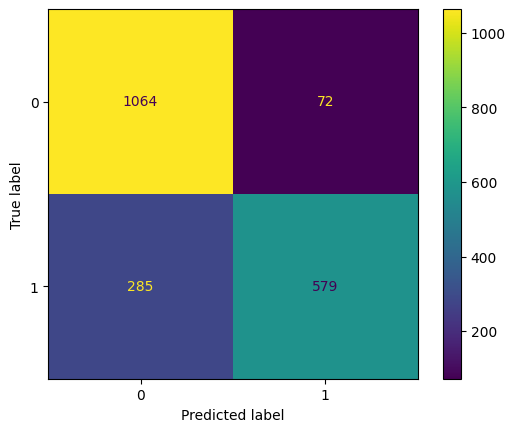

Classification accuracy for male or female: 82.2%
Xb: (32, 218, 178, 3) float64 0.0 1.0
yb: (32, 6) int64
First 10 y rows:
 [[0 1 0 0 1 0]
 [1 0 0 0 1 0]
 [1 1 0 1 0 0]
 [1 1 0 0 0 1]
 [1 1 0 0 0 1]
 [0 1 0 0 1 0]
 [0 1 0 0 1 0]
 [0 1 0 0 1 0]
 [0 0 0 0 1 0]
 [1 1 1 1 0 0]]
Unique values in y: [0 1]


In [ ]:

#*************************************************************************************************************************************
#R1 - Added some code to create a confusion matrix of the predictions
#*************************************************************************************************************************************

#confusion matrix currently only shows accuracy for one class = male


from sklearn import metrics
import matplotlib.pyplot as plt
#for i in prediction:

pclassified = np.zeros([test_size])
for i in range(test_size):
  pclassified[i] = classify_value(prediction[i,0], 0.5)

pclassified = pclassified.astype(int)

print(len(pclassified))

tclassified = np.zeros([test_size])
for i in range(test_size):
  tclassified[i] = test_array[i,1]

cm = metrics.confusion_matrix(tclassified, pclassified)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

cm_display.plot()
plt.show()


#confusion matrix accuracy reading
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

accuracy = ((TP + TN) / cm.sum())
print(f"Classification accuracy for male or female: {(accuracy):.1%}")

Xb, yb = train_generator[0]
print("Xb:", Xb.shape, Xb.dtype, Xb.min(), Xb.max())
print("yb:", yb.shape, yb.dtype)
print("First 10 y rows:\n", yb[:10])
print("Unique values in y:", np.unique(yb))

In [ ]:
#output seed and results to file
with open(output_file, "a") as f:
    f.write("New Session \n")
    f.write("Seed:" + str(SEED) + "\n")
    f.write("Accuracy:" + str(accuracy) + "\n")

print(f"Content appended to {output_file}")


Content appended to /content/drive/MyDrive/ImageRec/Seeds.txt


In [ ]:
#*************************************************************************************************************************************
#R - Accuracy based on age
#*************************************************************************************************************************************



